In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Engine Health Overview

In fleet management and automotive engineering, unscheduled vehicle downtime introduces massive operational bottlenecks and unexpected capital expenditures. Moving from reactive maintenance to a data-driven Predictive Maintenance framework allows fleet managers to anticipate mechanical issues before catastrophic failures occur. By analyzing telemetry and sensor data (such as engine temperatures, vibrations, and breakdown history), machine learning classifiers can identify structural anomalies and predict failure windows. This shifting strategy optimizes supply chain logistics for spare parts, extends asset lifespans, and significantly reduces maintenance overhead.

In [27]:
df = pd.read_csv('engine_data (1).csv')

In [29]:
df.head(2)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0


In [31]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Engine rpm,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2239.000000
Lub oil pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566
Fuel pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,21.138326
Coolant pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505
lub oil temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,89.580796
Coolant temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,195.527912
Engine Condition,19535.0,0.630509,0.482679,0.000000,0.000000,1.000000,1.000000,1.000000


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
 6   Engine Condition  19535 non-null  int64  
dtypes: float64(5), int64(2)
memory usage: 1.0 MB


No missing data

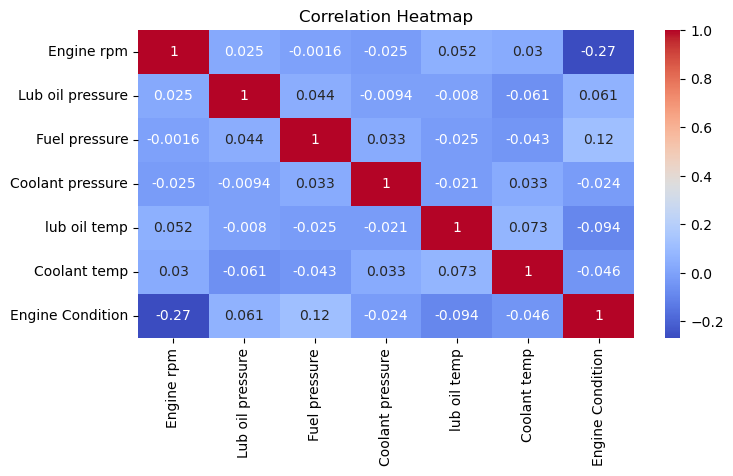

In [35]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

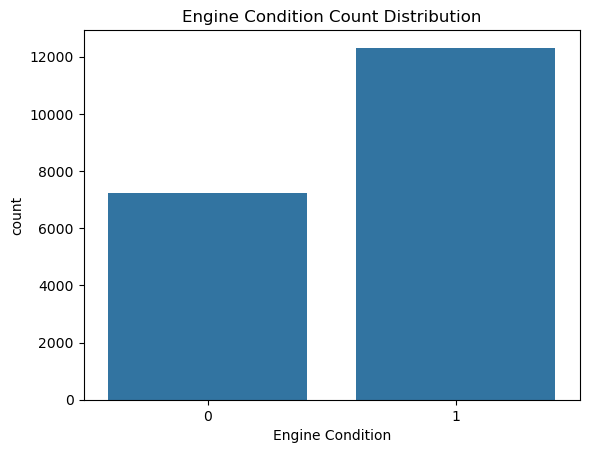

Engine Condition
1    12317
0     7218
Name: count, dtype: int64


In [37]:
sns.countplot(data=df, x='Engine Condition')
plt.title('Engine Condition Count Distribution')
plt.show()
print(df['Engine Condition'].value_counts())

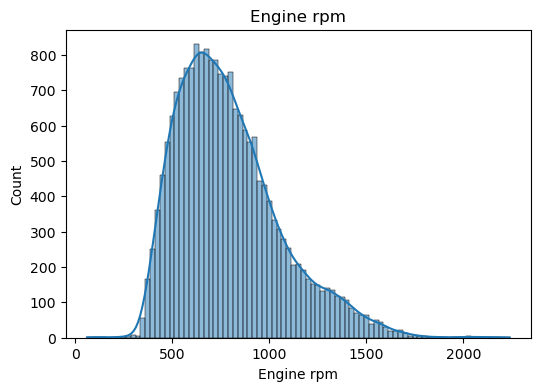

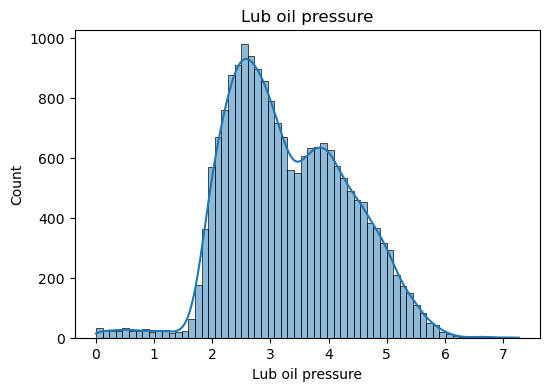

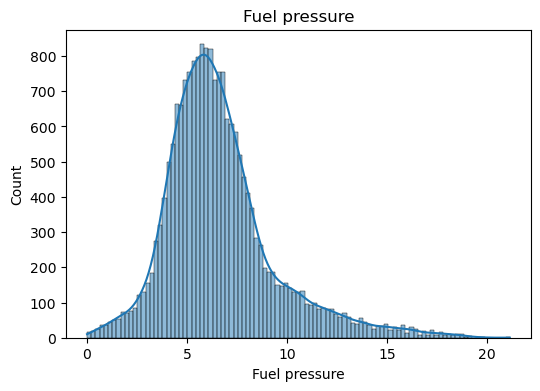

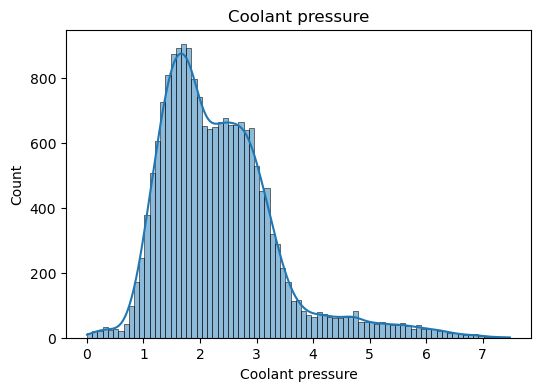

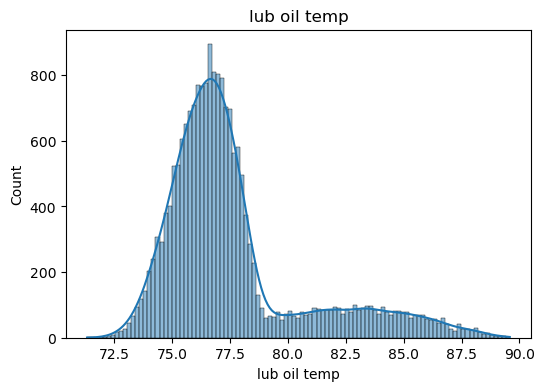

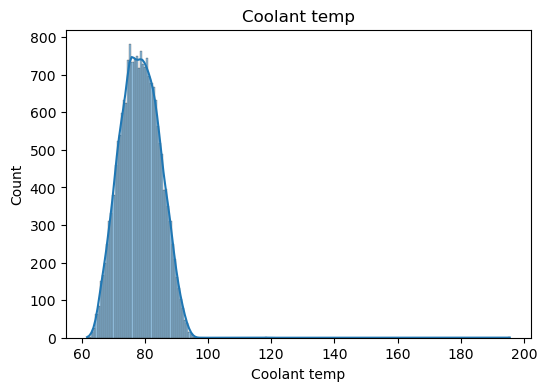

In [39]:
for col in df.columns[:-1]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

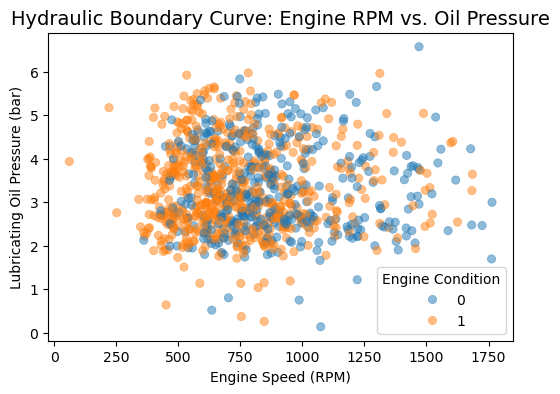

In [40]:
plt.subplots(figsize=(6, 4))
sns.scatterplot(data=df.sample(1000, random_state=42), x='Engine rpm', y='Lub oil pressure', hue='Engine Condition', alpha=0.5, edgecolor=None)
plt.title("Hydraulic Boundary Curve: Engine RPM vs. Oil Pressure", fontsize=14)
plt.xlabel("Engine Speed (RPM)")
plt.ylabel("Lubricating Oil Pressure (bar)")
plt.show()

df['Oil_pressure_rpm_ratio'] = df['Lub oil pressure'] / (df['Engine rpm'] + 1e-5)


df['Temp difference'] = (df['lub oil temp'] - df['Coolant temp']).abs()

During feature exploration, custom interaction terms—specifically the oil pressure-to-RPM ratio (Oil_pressure_rpm_ratio) and thermal gradient (Temp difference)—were engineered to capture physical thermodynamic boundaries within the engine. While these features provided deeper diagnostic clarity regarding mechanical stress interactions, their inclusion caused a 3% drop in model recall (decreasing from 38% to 35%). In predictive maintenance, maximizing recall is paramount to ensure that high-risk engine failures are not missed (minimizing false negatives). Because these variables introduced feature noise or multicollinearity that degraded the active model's classification sensitivity, they have been archived as markdown text. Retaining this logic preserves valuable domain insights for future diagnostic reference without compromising the core model's performance.

In [42]:
df.head(2)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0


In [43]:
df.to_csv(r'C:\Users\obian\OneDrive\Documents\SJ Lytix Projects\Engine Health\cleaned_data.csv',index=False)